In [1]:
!pip install librosa scikit-learn numpy matplotlib xgboost pandas seaborn


[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# -----------------------------
# ✅ IMPORTS AND CPU THREAD CONTROL
# -----------------------------
import os
os.environ["OMP_NUM_THREADS"] = "2"
os.environ["TF_NUM_INTRAOP_THREADS"] = "2"
os.environ["TF_NUM_INTEROP_THREADS"] = "2"

import numpy as np
import librosa
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
from tqdm import tqdm
import pandas as pd
import json
import random

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


Total number of audio files (all classes): 24459
Total audio files in classes with >= 500 files: 11000

Class counts (>= 500):
barswa - 500
bcnher - 500
bkwsti - 500
blrwar1 - 500
comgre - 500
comkin1 - 500
commoo3 - 500
comros - 500
comsan - 500
eaywag1 - 500
eucdov - 500
eurcoo - 500
graher1 - 500
grewar3 - 500
grnsan - 500
grywag - 500
hoopoe - 500
houspa - 500
lirplo - 500
litgre1 - 500
woosan - 500
zitcis1 - 500


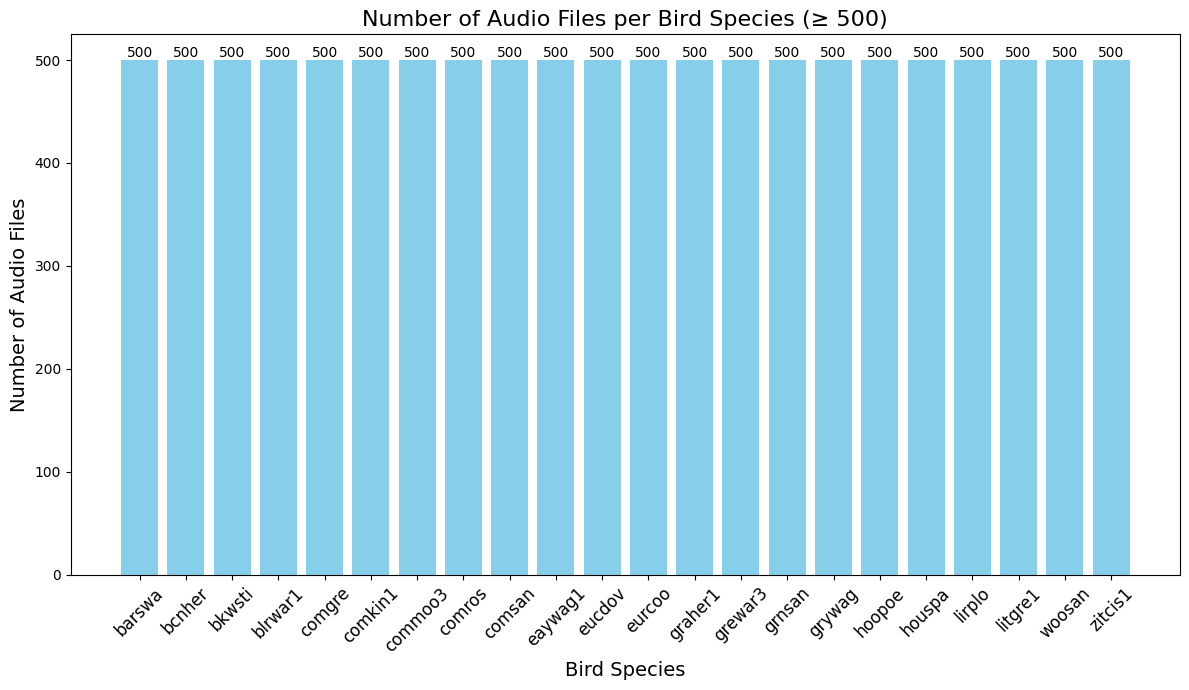

In [3]:
import os
import matplotlib.pyplot as plt

# Define your folder structure
data_dir = "train_audio_2024/"

# Automatically detect class folders
classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])

# Count the number of files for each class
class_counts = {}
total_files = 0
filtered_total_files = 0

for class_name in classes:
    class_path = os.path.join(data_dir, class_name)
    if os.path.exists(class_path):
        count = len([
            file for file in os.listdir(class_path)
            if os.path.isfile(os.path.join(class_path, file))
        ])
        total_files += count

        if count >= 500:  # ✅ Changed condition to >= 500
            class_counts[class_name] = count
            filtered_total_files += count

# ✅ Print total number of audio files
print(f"\nTotal number of audio files (all classes): {total_files}")
print(f"Total audio files in classes with >= 500 files: {filtered_total_files}")

# ✅ Print each class with its count (only those with count >= 500)
print("\nClass counts (>= 500):")
for class_name, count in class_counts.items():
    print(f"{class_name} - {count}")

# --- Optional: Plotting ---
labels = list(class_counts.keys())
values = list(class_counts.values())

plt.figure(figsize=(12, 7))
bars = plt.bar(labels, values, color='skyblue')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.5, f"{int(yval)}", ha='center', va='bottom', fontsize=10, color='black')

plt.title("Number of Audio Files per Bird Species (≥ 500)", fontsize=16)
plt.xlabel("Bird Species", fontsize=14)
plt.ylabel("Number of Audio Files", fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.tight_layout()

# Save or display
# plt.savefig("species_above_500.png", dpi=300, bbox_inches='tight')
plt.show()

Playing audio file: XC580725.ogg


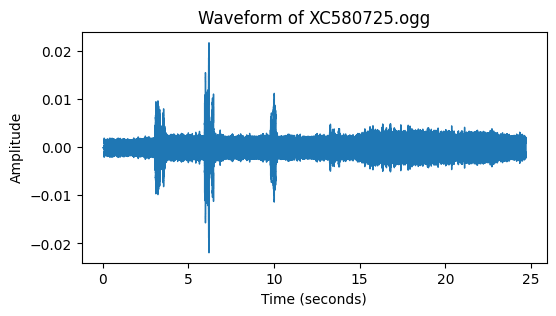

In [6]:
from IPython.display import Audio, display

# Define the species and dataset path
species = "comsan"
dataset_path = "train_audio_2024/"

# Path to the species folder
species_path = os.path.join(dataset_path, species)

# Check if species folder exists
if os.path.exists(species_path):
    # Get all `.ogg` files
    audio_files = [f for f in os.listdir(species_path) if f.endswith('.ogg')]
    
    if audio_files:
        # Select a random audio file
        selected_file = random.choice(audio_files)
        file_path = os.path.join(species_path, selected_file)
        
        print(f"Playing audio file: {selected_file}")
        
        # Load the audio file
        audio_data, sr = librosa.load(file_path, sr=None)
        
        # Plot waveform
        plt.figure(figsize=(6, 3))
        librosa.display.waveshow(audio_data, sr=sr)
        plt.title(f"Waveform of {selected_file}")
        plt.xlabel("Time (seconds)")
        plt.ylabel("Amplitude")
        plt.show()
        
        # Play the audio file
        display(Audio(file_path, autoplay=True))
    else:
        print("No audio files found for 'comgre'.")
else:
    print(f"Species folder '{species}' not found.")


# Load and Preprocess Audio Data

In [4]:
import os
import numpy as np
import librosa

# Load and preprocess audio data with chunking
def load_and_preprocess_data(data_dir, classes, min_files=500, chunk_duration=6, overlap_duration=2, n_mfcc=20):
    data = []
    labels = []

    # Count files per class
    class_counts = {}
    for class_name in classes:
        class_dir = os.path.join(data_dir, class_name)
        if os.path.exists(class_dir):
            count = len([file for file in os.listdir(class_dir) if file.endswith('.ogg')])
            class_counts[class_name] = count

    # Select classes with at least 500 files
    selected_classes = [cls for cls, count in class_counts.items() if count >= min_files]
    print("Selected Classes with ≥ 500 files:", selected_classes)

    # Process each selected class
    for class_name in selected_classes:
        class_dir = os.path.join(data_dir, class_name)
        print("Processing --", class_name)
        
        for filename in os.listdir(class_dir):
            if filename.endswith('.ogg'):
                file_path = os.path.join(class_dir, filename)
                audio_data, sample_rate = librosa.load(file_path, sr=None)

                chunk_samples = chunk_duration * sample_rate
                overlap_samples = overlap_duration * sample_rate
                num_chunks = int(np.ceil((len(audio_data) - chunk_samples) / (chunk_samples - overlap_samples))) + 1

                for i in range(num_chunks):
                    start = i * (chunk_samples - overlap_samples)
                    end = start + chunk_samples
                    chunk = audio_data[start:end]

                    if len(chunk) < chunk_samples:
                        chunk = np.pad(chunk, (0, chunk_samples - len(chunk)))

                    mfcc = librosa.feature.mfcc(y=chunk, sr=sample_rate, n_mfcc=n_mfcc)
                    mfcc = np.mean(mfcc, axis=1)  # Take mean across time

                    data.append(mfcc)
                    labels.append(class_name)

    return np.array(data), np.array(labels)


# --------------------
# ✅ RUN EXTRACTION
# --------------------
dataset_path = "train_audio_2024/"
all_classes = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]

X, y = load_and_preprocess_data(
    data_dir=dataset_path,
    classes=all_classes,
    min_files=500,
    chunk_duration=6,
    overlap_duration=2,
    n_mfcc=20
)

print("✅ Final Dataset Shape:", X.shape, y.shape)

# --------------------
# ✅ SAVE FEATURES
# --------------------
np.save("features_mfcc_X.npy", X)
np.save("labels_y.npy", y)
print("✅ Features and labels saved as 'features_mfcc_X.npy' and 'labels_y.npy'")

Selected Classes with ≥ 500 files: ['barswa', 'bcnher', 'bkwsti', 'blrwar1', 'comgre', 'comkin1', 'commoo3', 'comros', 'comsan', 'eaywag1', 'eucdov', 'eurcoo', 'graher1', 'grewar3', 'grnsan', 'grywag', 'hoopoe', 'houspa', 'lirplo', 'litgre1', 'woosan', 'zitcis1']
Processing -- barswa
Processing -- bcnher
Processing -- bkwsti
Processing -- blrwar1
Processing -- comgre
Processing -- comkin1
Processing -- commoo3
Processing -- comros
Processing -- comsan
Processing -- eaywag1
Processing -- eucdov
Processing -- eurcoo
Processing -- graher1
Processing -- grewar3
Processing -- grnsan
Processing -- grywag
Processing -- hoopoe
Processing -- houspa
Processing -- lirplo
Processing -- litgre1
Processing -- woosan
Processing -- zitcis1
✅ Final Dataset Shape: (127376, 20) (127376,)
✅ Features and labels saved as 'features_mfcc_X.npy' and 'labels_y.npy'


# 🛠 Encode labels

In [5]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split dataset into train and test sets

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

# 🛠 Step 4: Save and Load the Model

In [8]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    objective="multi:softmax",
    num_class=len(label_encoder.classes_),
    eval_metric="mlogloss",
    use_label_encoder=False,
    verbosity=1  # Show training messages
)

xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)],
    verbose=True)   # Show evaluation log at each iteration

C:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py:158: UserWarning: [05:41:39] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[0]	validation_0-mlogloss:2.53123
[1]	validation_0-mlogloss:2.34152
[2]	validation_0-mlogloss:2.20501
[3]	validation_0-mlogloss:2.09316
[4]	validation_0-mlogloss:2.00398
[5]	validation_0-mlogloss:1.93071
[6]	validation_0-mlogloss:1.86557
[7]	validation_0-mlogloss:1.80672
[8]	validation_0-mlogloss:1.75748
[9]	validation_0-mlogloss:1.71652
[10]	validation_0-mlogloss:1.67815
[11]	validation_0-mlogloss:1.63909
[12]	validation_0-mlogloss:1.60926
[13]	validation_0-mlogloss:1.57676
[14]	validation_0-mlogloss:1.55095
[15]	validation_0-mlogloss:1.52360
[16]	validation_0-mlogloss:1.49835
[17]	validation_0-mlogloss:1.47273
[18]	validation_0-mlogloss:1.45090
[19]	validation_0-mlogloss:1.42985
[20]	validation_0-mlogloss:1.41017
[21]	validation_0-mlogloss:1.39318
[22]	validation_0-mlogloss:1.37503
[23]	validation_0-mlogloss:1.35987
[24]	validation_0-mlogloss:1.34399
[25]	validation_0-mlogloss:1.33008
[26]	validation_0-mlogloss:1.31527
[27]	validation_0-mlogloss:1.30176
[28]	validation_0-mlogloss:1.2

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_class=22, num_parallel_tree=None, ...)

In [9]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Predict
y_pred = xgb_model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("✅ Accuracy:", acc)

✅ Accuracy: 0.7717459569791176


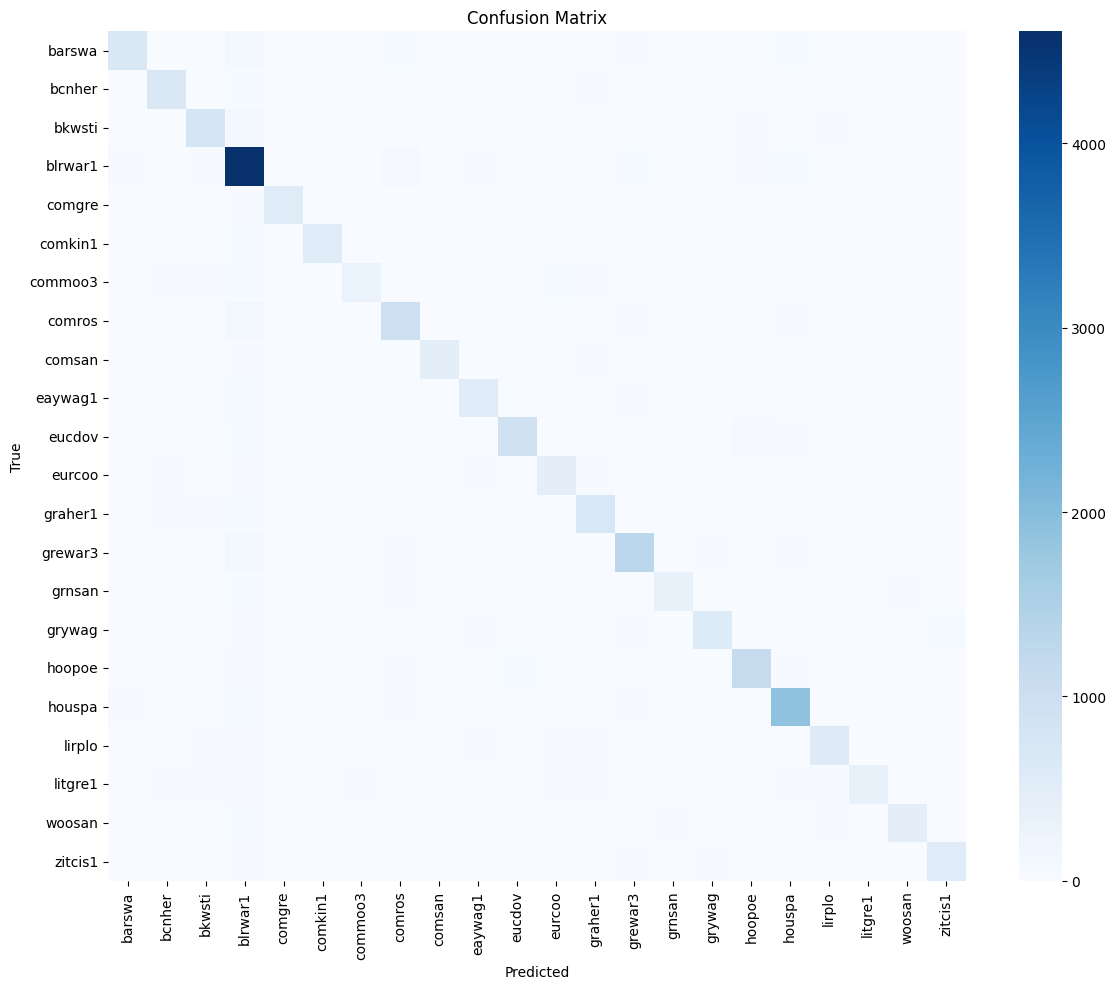


✅ Classification Report:

              precision    recall  f1-score   support

      barswa       0.80      0.66      0.72      1035
      bcnher       0.72      0.78      0.75       901
      bkwsti       0.76      0.73      0.75      1098
     blrwar1       0.79      0.93      0.85      4973
      comgre       0.78      0.75      0.77       765
     comkin1       0.83      0.72      0.77       780
     commoo3       0.72      0.54      0.61       596
      comros       0.73      0.73      0.73      1338
      comsan       0.80      0.71      0.75       670
     eaywag1       0.68      0.68      0.68       846
      eucdov       0.82      0.80      0.81      1132
      eurcoo       0.66      0.64      0.65       717
     graher1       0.69      0.73      0.71       994
     grewar3       0.80      0.81      0.81      1615
      grnsan       0.69      0.58      0.63       608
      grywag       0.73      0.72      0.73       848
      hoopoe       0.81      0.79      0.80      1461


In [10]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

# Optional: Classification Report
print("\n✅ Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))